# 5장 2강: 부스팅 계열 모델의 원리와 발전

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 부스팅 계열 모델의 순차 학습 원리와 주요 모델의 차이를 확인합니다.

- AdaBoost와 Gradient Boosting의 순차 학습 원리를 이해합니다.
- Gradient Boosting이 이전 모델의 잔차를 보완하는 흐름을 확인합니다.
- XGBoost와 LightGBM을 같은 데이터에서 비교합니다.
- `learning_rate`, `n_estimators`, `max_depth`의 역할을 확인합니다.
- Early Stopping의 목적을 이해합니다.
- 부스팅이 단계적으로 편향을 줄여가는 이유를 설명합니다.

> 이 실습에서는 5장 2강 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- lightgbm
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. 같은 데이터에서 Gradient Boosting, XGBoost, LightGBM을 비교합니다.

In [2]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 부스팅의 순차 학습 원리 확인

## 문제 1. AdaBoost와 Gradient Boosting의 차이를 정리하세요.

### 요구사항

다음 두 모델이 이전 모델의 실수를 어떻게 보완하는지 각각 작성합니다.

- AdaBoost
- Gradient Boosting

### 확인 포인트

- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는가?
- Gradient Boosting은 이전 모델의 잔차를 다음 모델이 학습하는가?

### Q1. AdaBoost와 Gradient Boosting은 각각 무엇에 집중하여 다음 모델을 학습하나요?

**답변:**  AdaBoost는 샘플 가중치에 집중한다. 이전 모델이 크게 틀린 샘플의 가중치를 높이고 잘 맞춘 샘플의 가중치는 낮춘다. 그래서 다음 모델은 어려운 샘플을 더 신경써 학습한다. Gradient Boosting은 residual에 집중한다. 다음 모델은 원래 정답 y가 아닌 잔차를 타깃으로 학습한다. 이 잔차는 손실함수의 기울기에 해당하고 오차를 단계적으로 줄여나가는 방식이다.

## 문제 2. Gradient Boosting의 단계별 성능 변화를 확인하세요.

### 요구사항

1. `GradientBoostingRegressor`를 사용합니다.
2. `n_estimators=100`
3. `learning_rate=0.05`
4. `max_depth=2`
5. `random_state=42`
6. 모델을 학습합니다.
7. `staged_predict()`를 사용해 나무가 추가될 때마다 Test RMSE를 계산합니다.
8. 나무 개수에 따른 Test RMSE를 선 그래프로 나타냅니다.

### 확인 포인트

- 순차적으로 나무가 추가되면서 예측 오차가 감소하는 구간을 확인했는가?
- 이전까지 설명하지 못한 부분을 다음 나무가 보완한다는 개념과 연결할 수 있는가?

In [4]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

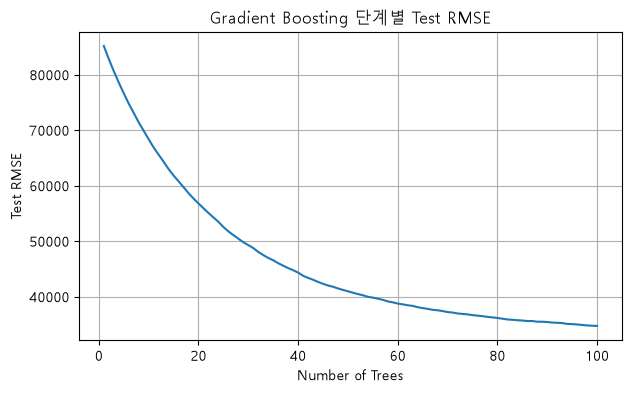

나무 1개 RMSE  : 85,178
나무 100개 RMSE: 34,716
최소 RMSE 시점 : 100번째 나무


In [ ]:
# TODO
# GradientBoostingRegressor를 학습하고
# staged_predict()를 이용해 단계별 Test RMSE를 확인하세요.
import numpy as np
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
gb.fit(X_train, y_train)

test_rmse = []
for pred in gb.staged_predict(X_test):  
    rmse = np.sqrt(mean_squared_error(y_test, pred))  
    test_rmse.append(rmse)
    
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(test_rmse) + 1), test_rmse)
plt.xlabel("Number of Trees")
plt.ylabel("Test RMSE")
plt.title("Gradient Boosting 단계별 Test RMSE")
plt.grid(True)
plt.show()

print(f"나무 1개 RMSE  : {test_rmse[0]:,.0f}")
print(f"나무 100개 RMSE: {test_rmse[-1]:,.0f}")
print(f"최소 RMSE 시점 : {np.argmin(test_rmse) + 1}번째 나무")

### Q2. 부스팅에서 나무를 순차적으로 추가하는 이유는 무엇인가요?

**답변:**  부스팅은 각 나무가 이전 나무들이 남긴 오차를 보고 학습해야 하기 때문에 순차적으로 나무를 추가한다. 이전 단계의 예측이 정해져야 잔차를 계산할 수 있으므로, 병렬로 동시에 학습할 수 없다(순차적 계산).

---

# 필수 2. XGBoost와 LightGBM 비교

## 문제 1. 두 모델을 같은 조건에서 학습하세요.

### 요구사항

다음 공통 설정을 사용합니다.

- `n_estimators=200`
- `learning_rate=0.05`
- `max_depth=3`
- `random_state=42`

다음 두 모델을 학습합니다.

- `XGBRegressor`
- `LGBMRegressor`

각 모델에 대해 다음을 확인합니다.

1. 학습 시간
2. Test RMSE

### 확인 포인트

- XGBoost와 LightGBM을 같은 데이터와 같은 주요 하이퍼파라미터 조건에서 비교했는가?
- LightGBM이 빠른 학습을 강점으로 갖는다는 교안 내용과 연결할 수 있는가?

In [7]:
# TODO
# XGBoost와 LightGBM의 학습 시간과 Test RMSE를 비교하세요.
models = {
    'XgBoost': XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    )
}
result = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time() - start
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    result.append({'모델': name, '학습시간': end, 'rmse': rmse})

display(pd.DataFrame(result))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1378
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 12
[LightGBM] [Info] Start training from score 181441.541952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

,모델,학습시간,rmse
0,XgBoost,0.168236,28405.320065
1,LightGBM,0.055033,31813.091613


### Q3. XGBoost와 LightGBM의 기본 트리 성장 방식 차이는 무엇인가요?

**답변:**  XGBoost는 기본적으로 레벨 단위로 성장한다. 같은 깊이의 노드를 모두 분할한 뒤 다음 깊이로 내려가서, 균형 잡힌 나무가 만들어진다. LightGBM은 리프 단위로 성장한다. 전체 리프 중에서 손실을 가장 많이 줄이는 리프 하나만 골라 계속 분할해서, 비대칭적이고 깊은 나무가 만들어질 수 있다. 같은 분할 횟수로 손실을 더 빨리 줄일 수 있어 빠르고 효율적이다. 다만 데이터가 작으면 과적합되기 쉬워서 num_leaves, max_depth 등으로 제한하는 것이 중요하다.

### Q4. CatBoost의 구조적 특징과 강점은 무엇인가요?

**답변:**  범주형 변수 처리에 특화된 모델이다. 범주형 변수를 원-핫 인코딩하지 않고 타깃 통계로 인코딩한다. 이때 순서를 섞어 "현재 샘플 이전 데이터"만 써서 타깃 누수를 막는다(Ordered Target Statistics). 잔차 계산에서 생기는 편향도 Ordered Boosting으로 줄인다. 같은 깊이의 모든 노드가 같은 분할 기준을 쓰는 대칭 트리(oblivious tree)를 사용해 예측이 빠르고 과적합에 비교적 강하다. 기본 하이퍼파라미터만으로도 성능이 잘 나와 튜닝 부담이 적다는 것이 큰 장점이다. 

## 문제 2. learning_rate와 n_estimators의 관계를 확인하세요.

### 요구사항

다음 조합을 비교합니다.

```python
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]
```

각 조합에 대해 `GradientBoostingRegressor(max_depth=2, random_state=42)`를 학습하고 다음을 확인합니다.

1. Test RMSE
2. 학습 시간

### 확인 포인트

- learning_rate가 작을수록 더 많은 나무가 필요할 수 있음을 확인했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [15]:
# TODO
# learning_rate / n_estimators 조합별 Test RMSE와 학습 시간을 비교하세요.
settings = [
    {'learning_rate': 0.1, 'n_estimators': 50},
    {'learning_rate': 0.05, 'n_estimators': 100},
    {'learning_rate': 0.01, 'n_estimators': 300}
]

result = []
for i in settings:
    lr = i['learning_rate']
    n = i['n_estimators']

    model = GradientBoostingRegressor(
        learning_rate=lr,
        n_estimators=n,
        max_depth=2,
        random_state=42
    )

    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    result.append({
        'learning_rate': lr,
        'n_estimators': n,
        '학습시간': elapsed,
        'rmse': rmse
    })

display(pd.DataFrame(result))

,learning_rate,n_estimators,학습시간,rmse
0,0.10,50,0.042275,34913.186227
1,0.05,100,0.064688,34715.577679
2,0.01,300,0.179046,39072.053577


### Q5. learning_rate를 작게 만들면 왜 n_estimators를 함께 늘려야 할 수 있나요?

**답변:**  learning_rate는 각 나무의 예측을 얼마나 반영할지 정하는 보폭이다. 값이 작으면 나무 하나가 오차를 조금만 줄이기 때문에, 같은 수준까지 오차를 줄이려면 더 많은 나무가 필요하다. 대략 learning_rate를 절반으로 줄이면 나무를 두 배로 늘려야 비슷한 학습량이 된다. 이번 결과의 0.01 조합처럼 나무를 충분히 늘리지 않으면 과소적합이 생긴다. learning_rate를 작게 하고 나무를 많이 쓰면 더 세밀하게 학습해서 일반화 성능이 좋아질 수 있지만, 학습 시간이 늘어난다.

---

# 과제 1. Early Stopping과 부스팅 모델 선택

## 배경

교안에서는 `n_estimators`를 충분히 크게 설정하고, 검증 성능이 더 이상 좋아지지 않으면 학습을 멈추는 **Early Stopping**을 소개했습니다.

이번 과제에서는 XGBoost에서 이 흐름을 적용합니다.

> 과제는 필수 실습에서 사용한 모델과 하이퍼파라미터를 그대로 활용하는 수준입니다.

## 요구사항

1. Train 데이터를 다시 Train / Validation으로 나눕니다.
2. `XGBRegressor`를 사용합니다.
3. `n_estimators=1000`
4. `learning_rate=0.05`
5. `max_depth=3`
6. `early_stopping_rounds=20`
7. Train 데이터로 학습하고 Validation 데이터를 `eval_set`으로 전달합니다.
8. Test 데이터의 RMSE를 계산합니다.
9. 실제로 사용된 나무 수를 확인합니다.
10. `n_estimators=1000`을 모두 사용하지 않고 중간에 멈췄다면 그 이유를 설명합니다.

11. Q7에서 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산, 과적합에 미치는 영향을 비교합니다. 새로운 모델 학습 코드는 요구하지 않습니다.

### 확인 포인트

- Early Stopping이 Validation 성능을 기준으로 동작한다는 점을 이해했는가?
- 불필요하게 많은 나무를 쌓는 것을 막는 목적을 설명할 수 있는가?
- 과적합 방지와 학습 시간 절약이라는 두 가지 의미를 설명할 수 있는가?
- 배깅의 부트스트랩·예측 결합, 랜덤포레스트의 특성 무작위 선택, 부스팅의 순차적 오류 보완을 설명할 수 있는가?
- 각 방식이 편향·분산에 미치는 일반적인 영향과 과적합 가능성을 구분할 수 있는가?


In [22]:
# TODO
# XGBoost에 Early Stopping을 적용하세요.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=3,
    early_stopping_rounds=20, random_state=42
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
test_rmse = np.sqrt(mean_squared_error(y_test, xgb.predict(X_test)))
n_rounds_run = len(xgb.evals_result()['validation_0']['rmse'])
print(f"Best iteration (0부터 시작): {xgb.best_iteration}")
print(f"실제 사용된 나무 수        : {xgb.best_iteration + 1}")
print(f"학습이 멈춘 시점           : {n_rounds_run}번째 나무")
print(f"Best Validation RMSE       : {xgb.best_score:,.0f}")
print(f"Test RMSE                  : {test_rmse:,.0f}")


Best iteration (0부터 시작): 113
실제 사용된 나무 수        : 114
학습이 멈춘 시점           : 134번째 나무
Best Validation RMSE       : 31,437
Test RMSE                  : 37,359


### Q6. Early Stopping은 어떤 상황에서 학습을 멈추나요?

**답변:**  Early Stopping은 Validation 데이터의 성능이 지정한 라운드 수 동안 연속으로 개선되지 않을 때 학습을 멈춘다. 그리고 Validation 성능이 가장 좋았던 시점의 모델을 사용한다. 여기에는 두 가지 의미가 있다. 과적합 방지의 면에서 Train 오차는 계속 줄어도 Validation 오차가 나빠지기 시작하는 시점 이후의 나무는 쌓지 않는다. 학습 시간 절약의 면에서 1000개를 모두 학습하지 않고 134개에서 멈췄으므로 불필요한 계산을 줄였다. 판단 기준이 Test가 아니라 Validation이어야 한다. Test로 멈추는 시점을 정하면 Test 정보가 학습에 새어 들어가는 데이터 누수가 생긴다.

### Q7. 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산에 미치는 영향을 비교하세요.

다음 항목을 포함하여 각 방법을 설명하세요.

1. **배깅:** 부트스트랩 표본을 만드는 방법과 여러 모델의 예측을 결합하는 방법, 분산 감소의 이유
2. **랜덤포레스트:** 배깅에 더해 각 노드의 분할 후보 특성을 무작위로 선택하는 이유와 트리 간 상관·분산에 미치는 영향
3. **부스팅:** 이전 모델의 오류를 순차적으로 보완하는 원리와 편향 감소의 관계, 과적합 가능성 및 이를 줄이는 방법

> 편향·분산에 대한 효과는 일반적인 경향입니다. 한 방법이 편향 또는 분산만 바꾸거나 과적합을 항상 막는다고 단정하지 마세요.

**답변:**

- 배깅: 학습 데이터에서 복원추출(부트스트랩)로 여러 표본을 만들고, 각각 모델을 따로 학습한다. 회귀는 예측을 평균내고 분류는 다수결로 합친다. 모델마다 학습 데이터가 달라 오차도 다르게 나오는데, 이를 평균내면 서로 상쇄되어 분산이 줄어든다. 편향은 거의 그대로라서, 분산이 큰 깊은 결정나무와 잘 맞는다.
- 랜덤포레스트: 배깅에 더해 노드를 나눌 때마다 특성 일부만 무작위로 골라 분할 후보로 쓴다. 이렇게 하지 않으면 OverallQual 같은 강한 특성이 매번 먼저 선택되어 나무들이 비슷해진다. 특성을 무작위로 고르면 트리 간 상관이 낮아져서, 평균을 냈을 때 배깅보다 분산이 더 줄어든다. 대신 개별 나무의 편향은 조금 커질 수 있다.
- 부스팅: 얕은 나무를 순차적으로 학습하면서, 이전 모델이 틀린 부분을 다음 모델이 보완한다. 단계적으로 오차를 줄여가므로 주로 편향을 줄인다. 하지만 나무를 너무 많이 쌓으면 잡음까지 학습해 과적합될 수 있다. 이를 막기 위해 learning_rate를 작게 하거나, max_depth를 제한하거나, Early Stopping을 사용한다. 이번 과제에서도 1000개 중 134개만 사용되었다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 부스팅은 여러 모델을 병렬로 학습하나요, 순차적으로 학습하나요?
2. AdaBoost는 이전 모델이 틀린 샘플을 어떻게 처리하나요?
3. Gradient Boosting은 다음 모델이 무엇을 학습하나요?
4. XGBoost와 LightGBM의 기본 트리 성장 방식은 어떻게 다른가요?
5. `learning_rate`와 `n_estimators`는 어떤 관계가 있나요?
6. Early Stopping을 사용하는 이유는 무엇인가요?
7. 부스팅은 편향과 분산 중 어떤 문제를 줄이는 데 특히 초점을 두나요?

- 부스팅은 이전 모델의 결과를 보고 다음 모델을 학습하므로 순차적으로 학습해요.
- AdaBoost는 이전 모델이 틀린 샘플의 가중치를 높여서, 다음 모델이 그 샘플을 더 중점적으로 학습하게 해요.
- Gradient Boosting에서 다음 모델은 이전까지의 예측이 남긴 잔차(손실함수의 음의 기울기)를 학습해요.
- XGBoost는 기본적으로 레벨 단위(level-wise)로 나무를 키우고, LightGBM은 손실을 가장 많이 줄이는 리프부터 키우는 리프 단위(leaf-wise) 방식을 써요.
- learning_rate와 n_estimators는 반비례 관계에 가까워요. learning_rate가 작을수록 나무 하나의 반영 비율이 작아서 더 많은 나무가 필요해요.
- Early Stopping은 Validation 성능이 더 이상 좋아지지 않을 때 학습을 멈춰요. 그래서 과적합을 막고 학습 시간을 절약할 수 있어요.
- 부스팅은 약한 모델의 오차를 단계적으로 보완하므로 특히 편향을 줄이는 데 초점을 둬요.

# 5장 정리: 앙상블(배깅·부스팅)과 모델 해석

## 1강. 배깅과 랜덤포레스트

깊이 제한 없는 결정나무 하나는 학습 데이터를 거의 외워버린다. 실습에서도 Train R²는 0.9999였지만 Test R²는 0.794로 크게 떨어졌다. 이런 모델은 편향은 낮고 **분산이 큰** 모델이다.

**배깅**은 원본 데이터에서 같은 크기만큼 복원추출(부트스트랩)해서 여러 표본을 만들고, 각 표본으로 모델을 독립적으로 학습한 뒤 평균(회귀) 또는 다수결(분류)로 합친다. 모델마다 오차가 다르게 나오고, 이를 평균내면 서로 상쇄되어 분산이 줄어든다. 실습에서는 Test R²가 0.794에서 0.891로 올랐다.

**랜덤포레스트**는 배깅에 더해, 노드를 나눌 때마다 특성 일부만 무작위로 후보로 쓴다. 평균의 분산은 ρσ² + (1−ρ)σ²/B인데, 나무 수 B를 늘려도 ρσ²는 남는다. 그래서 트리 간 상관 ρ 자체를 낮추려고 특성을 무작위로 고르는 것이다. 실습에서도 나무를 1개에서 10개로 늘릴 때는 성능이 크게 올랐지만, 50개 이후로는 거의 변하지 않았다.

**OOB(Out-Of-Bag)**는 부트스트랩에서 뽑히지 않은 약 36.8%(e⁻¹)의 데이터다. 별도 검증 데이터 없이 성능을 추정하는 데 쓸 수 있다. 다만 각 샘플을 일부 나무로만 예측하므로 실제보다 약간 낮게 나올 수 있다. 실습에서는 OOB 0.819, Test 0.890이었다.

**Feature Importance**는 분기에서 오차를 많이 줄인 특성일수록 높게 나온다. 예측에 많이 쓰였다는 뜻이지 인과관계를 의미하지는 않는다.

## 2강. 부스팅 계열 모델

부스팅은 얕은 나무를 **순차적으로** 추가하면서 이전 모델이 틀린 부분을 보완한다. 주로 **편향**을 줄이는 방식이다. AdaBoost는 틀린 샘플의 가중치를 높이고, Gradient Boosting은 잔차를 다음 나무의 타깃으로 쓴다. 실습에서 staged_predict로 확인해보니, 나무가 추가될수록 Test RMSE가 85,133에서 32,559로 꾸준히 내려갔다.

**learning_rate와 n_estimators**는 반비례 관계에 가깝다. 실습에서 (0.1, 50)과 (0.05, 100)은 RMSE가 비슷했지만, (0.01, 300)은 나무가 부족해 과소적합되었고 RMSE도 37,166으로 가장 나빴다.

**Early Stopping**은 Validation 성능이 일정 라운드 동안 개선되지 않으면 학습을 멈춘다. 실습에서는 n_estimators=1000으로 설정했지만 108개만 사용되었다. 과적합을 막고 학습 시간을 아낄 수 있다. 멈추는 기준은 반드시 Test가 아니라 Validation이어야 한다.

## 3강. 배깅 vs 부스팅 선택과 SHAP

같은 데이터에서 RF와 XGBoost를 비교했더니 XGBoost가 Validation RMSE가 더 낮았고(27,437 vs 29,318), Train-Val 차이도 작아 과적합 징후가 덜했다. 일반적인 선택 기준은 다음과 같다.

| 상황 | 우선 후보 |
|---|---|
| 빠른 베이스라인, 튜닝 여력 적음 | 랜덤포레스트 |
| 시간을 들여 성능 극대화 | 부스팅 (XGBoost, LightGBM 등) |
| 노이즈가 많아 과적합이 걱정됨 | 랜덤포레스트 |

**SHAP**은 각 샘플의 예측값을 "기준값 + 특성별 기여도의 합"으로 분해한다. 양수는 예측을 올렸다는 뜻이고, 음수는 내렸다는 뜻이다. 실습에서 기준값 + SHAP 합(149,904.39)과 예측값(149,904.42)이 거의 같은 것을 확인했다. 여러 샘플의 |SHAP|을 평균내면 **전역 해석**, 샘플 하나를 보면 **지역 해석**이 된다. 전역 1위 특성이 개별 주택에서도 항상 1위는 아니다.

Feature Importance와 SHAP의 순위는 다를 수 있다. GarageCars는 FI 2위였지만 SHAP 7위였다. 또 SHAP 상위 6개 특성만 골라 재학습했더니 오히려 RMSE가 9.45% 나빠졌다. 중요도가 낮은 특성도 다른 특성이 설명하지 못하는 정보를 갖고 있을 수 있다는 뜻이다.

---

# 부스팅 모델 종류 소개

## AdaBoost (1995)

부스팅의 시작점이 된 모델이다. 처음에는 모든 샘플에 같은 가중치를 주고, 모델이 틀린 샘플의 가중치를 높여 다음 모델이 그 샘플에 집중하게 한다. 최종 예측은 각 모델의 정확도에 따라 가중치를 준 투표(또는 가중 평균)다. 보통 깊이 1짜리 나무(stump)를 기본 모델로 쓴다. 구조가 단순하고 이해하기 쉽지만, 틀린 샘플에 계속 가중치를 주기 때문에 **이상치와 노이즈에 약하다**. 요즘은 실무보다 원리를 배우는 용도로 많이 쓴다.

## Gradient Boosting (GBM, 2001)

다음 나무가 "정답 − 현재 예측", 즉 잔차를 학습한다. 이 잔차는 손실함수의 음의 기울기와 같아서, 경사하강법을 함수 공간에서 하는 것으로 볼 수 있다. 손실함수를 바꿀 수 있어서 회귀와 분류 모두에 쓸 수 있다. 성능은 좋지만 정규화 장치가 적어 과적합되기 쉽고, 모든 분할 후보를 다 확인하기 때문에 **데이터가 크면 느리다**. sklearn의 `GradientBoostingRegressor`가 이 방식이다. 이후의 XGBoost, LightGBM, CatBoost는 모두 GBM을 개선한 모델이다.

## XGBoost (2014)

GBM을 빠르고 과적합에 강하게 만든 모델이다. 목적함수에 **L1/L2 정규화 항**을 넣어 나무가 너무 복잡해지지 않게 한다. 손실의 2차 미분까지 사용해 더 정확하게 최적화한다. 결측치가 있으면 왼쪽과 오른쪽 중 어느 방향으로 보낼지 자동으로 학습하고, 분할 탐색을 병렬로 처리한다. 기본적으로 **레벨 단위(level-wise)**로 나무를 키워서 균형 잡힌 나무가 만들어진다. Kaggle 등 대회에서 오랫동안 표준처럼 쓰였고, 안정적이고 자료도 많다는 것이 장점이다.

## LightGBM (2017, Microsoft)

**속도와 메모리 효율**에 집중한 모델이다. 연속값을 구간(bin)으로 묶는 히스토그램 방식으로 분할 후보 수를 크게 줄인다. 손실을 가장 많이 줄이는 리프부터 키우는 **리프 단위(leaf-wise)** 성장 방식을 쓴다. 기울기가 작은 샘플 일부를 덜 쓰는 GOSS, 동시에 0이 아닌 경우가 드문 특성들을 묶는 EFB 같은 기법도 들어 있다. 수십만 행 이상의 대용량 데이터에서 XGBoost보다 훨씬 빠른 경우가 많다. 다만 작은 데이터에서는 리프 단위 성장 때문에 과적합되기 쉬워 `num_leaves`, `min_child_samples` 조절이 중요하다. 실습 데이터는 약 1,100행이라 속도 차이가 거의 없었다.

## CatBoost (2017, Yandex)

**범주형 변수 처리**에 특화된 모델이다. 범주형 변수를 원-핫 인코딩하지 않고 타깃 통계로 인코딩한다. 이때 순서를 섞어 "현재 샘플 이전 데이터"만 써서 타깃 누수를 막는다(Ordered Target Statistics). 잔차 계산에서 생기는 편향도 Ordered Boosting으로 줄인다. 같은 깊이의 모든 노드가 같은 분할 기준을 쓰는 **대칭 트리(oblivious tree)**를 사용해 예측이 빠르고 과적합에 비교적 강하다. 기본 하이퍼파라미터만으로도 성능이 잘 나와 **튜닝 부담이 적다**는 것이 큰 장점이다. 반면 학습 속도는 LightGBM보다 느린 편이다.

## 한눈에 비교

| 모델 | 핵심 아이디어 | 트리 성장 | 강점 | 약점 |
|---|---|---|---|---|
| AdaBoost | 틀린 샘플 가중치↑ | stump 위주 | 단순, 이해 쉬움 | 이상치·노이즈에 약함 |
| GBM | 잔차(기울기) 학습 | 레벨 단위 | 유연한 손실함수 | 느림, 과적합 쉬움 |
| XGBoost | 정규화 + 2차 미분 | 레벨 단위 | 안정적, 결측치 자동 처리 | 대용량에선 LightGBM보다 느림 |
| LightGBM | 히스토그램 + GOSS/EFB | 리프 단위 | 매우 빠름, 메모리 효율 | 작은 데이터에서 과적합 주의 |
| CatBoost | 범주형 처리 + Ordered Boosting | 대칭 트리 | 범주형에 강함, 튜닝 부담 적음 | 학습 속도 상대적으로 느림 |

모델 선택 기준을 간단히 정리하면 다음과 같다. 숫자형 위주의 중간 크기 데이터라면 XGBoost, 데이터가 크고 속도가 중요하면 LightGBM, 범주형 변수가 많으면 CatBoost를 먼저 고려하면 된다. 다만 데이터에 따라 결과가 달라지므로, 실제로는 같은 Validation 조건에서 직접 비교해보는 것이 가장 확실하다.